
########################################

Classifier performance on training dataset

              precision    recall  f1-score   support

     Class-0       0.89      0.83      0.86       221
     Class-1       0.82      0.84      0.83       230
     Class-2       0.83      0.86      0.85       224

    accuracy                           0.85       675
   macro avg       0.85      0.85      0.85       675
weighted avg       0.85      0.85      0.85       675

########################################

########################################

Classifier performance on test dataset

              precision    recall  f1-score   support

     Class-0       0.92      0.85      0.88        79
     Class-1       0.84      0.84      0.84        70
     Class-2       0.85      0.92      0.89        76

    accuracy                           0.87       225
   macro avg       0.87      0.87      0.87       225
weighted avg       0.87      0.87      0.87       225

###########################

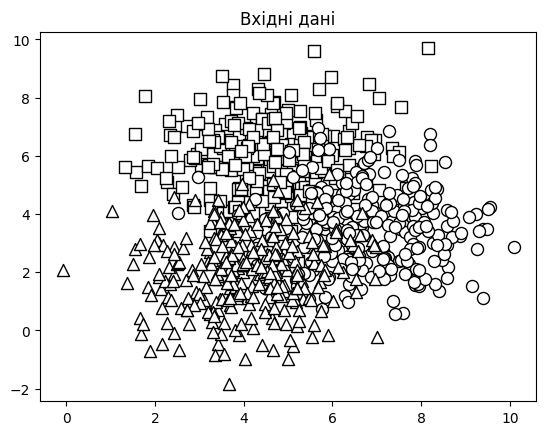

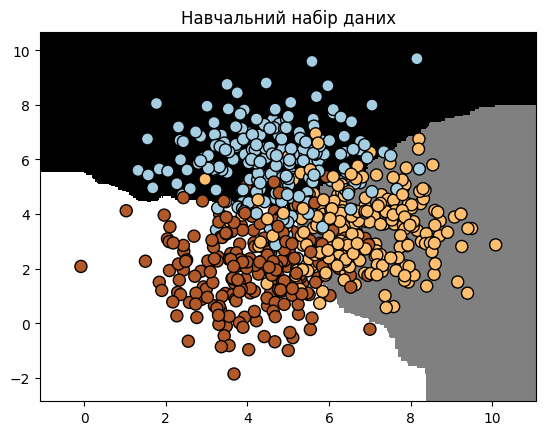

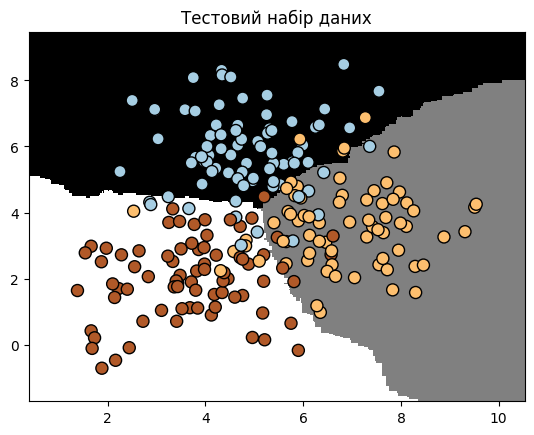

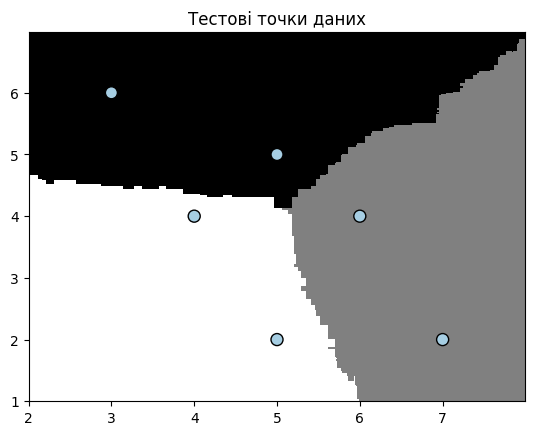

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

def visualize_classifier(classifier, X, y, title=''):
    min_x, max_x = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    min_y, max_y = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    mesh_step_size = 0.01
    x_vals, y_vals = np.meshgrid(np.arange(min_x, max_x, mesh_step_size), 
                                 np.arange(min_y, max_y, mesh_step_size))
    output = classifier.predict(np.c_[x_vals.ravel(), y_vals.ravel()])
    output = output.reshape(x_vals.shape)
    plt.figure()
    plt.pcolormesh(x_vals, y_vals, output, cmap=plt.cm.gray)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=75, edgecolors='black', linewidth=1, cmap=plt.cm.Paired)
    plt.xlim(x_vals.min(), x_vals.max())
    plt.ylim(y_vals.min(), y_vals.max())
    plt.title(title)

classifier_type = 'erf' 

input_file = 'data_random_forests.txt'
data = np.loadtxt(input_file, delimiter=',')
X, y = data[:, :-1], data[:, -1]

# Розбиття вхідних даних на три класи
class_0 = np.array(X[y==0])
class_1 = np.array(X[y==1])
class_2 = np.array(X[y==2])

# Візуалізація вхідних даних
plt.figure()
plt.scatter(class_0[:, 0], class_0[:, 1], s=75, facecolors='white', edgecolors='black', linewidth=1, marker='s')
plt.scatter(class_1[:, 0], class_1[:, 1], s=75, facecolors='white', edgecolors='black', linewidth=1, marker='o')
plt.scatter(class_2[:, 0], class_2[:, 1], s=75, facecolors='white', edgecolors='black', linewidth=1, marker='^')
plt.title('Вхідні дані')

# Розбивка даних на навчальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=5)

# Класифікатор на основі ансамблевого навчання
params = {'n_estimators': 100, 'max_depth': 4, 'random_state': 0}

if classifier_type == 'rf':
    classifier = RandomForestClassifier(**params)
else:
    classifier = ExtraTreesClassifier(**params)

# Навчання та малювання графіка тренувальних даних
classifier.fit(X_train, y_train)
visualize_classifier(classifier, X_train, y_train, 'Навчальний набір даних')

# Малювання графіка тестових даних
y_test_pred = classifier.predict(X_test)
visualize_classifier(classifier, X_test, y_test, 'Тестовий набір даних')

# Перевірка роботи класифікатора
class_names = ['Class-0', 'Class-1', 'Class-2']
print("\n" + "#"*40)
print("\nClassifier performance on training dataset\n")
print(classification_report(y_train, classifier.predict(X_train), target_names=class_names))
print("#"*40 + "\n")

print("#"*40)
print("\nClassifier performance on test dataset\n")
print(classification_report(y_test, y_test_pred, target_names=class_names))
print("#"*40 + "\n")

# Обчислення параметрів довірливості
test_datapoints = np.array([[5, 5], [3, 6], [6, 4], [7, 2], [4, 4], [5, 2]])
print("\nConfidence measure:")
for datapoint in test_datapoints:
    probabilities = classifier.predict_proba([datapoint])[0]
    predicted_class = 'Class-' + str(np.argmax(probabilities))
    print('\nDatapoint:', datapoint)
    print('Predicted class:', predicted_class)

# Візуалізація точок даних
visualize_classifier(classifier, test_datapoints, [0]*len(test_datapoints), 'Тестові точки даних')
plt.show()